# Лабораторная работа №1. Регрессия и метод главных компонент

## 1. Введение

**Цель работы** - изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Задачи:**

1. Загрузить датасет Boston Housing (boston_housing.csv).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Построить график остатков моделей (добавить горизонтальную линию на уровне 0) и исследовать структуру остатков на предмет гомоскедастичности или гетероскедастичности.
7. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
8. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Целевая переменная непрерывная - медианная цена жилья, потому логистическая регрессия здесь не нужна.


## 2. Описание датасета

Датасет [Boston Housing dataset](https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset). 506 строк, 13 столбцов.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110

RU_NAMES = {
    "crim": "Преступность",
    "zn": "Крупные участки",
    "indus": "Доля промзон",
    "chas": "Река Чарльз",
    "nox": "Оксиды азота",
    "rm": "Число комнат",
    "age": "Старый жилфонд",
    "dis": "Удалённость",
    "tax": "Налог",
    "ptratio": "Ученики/учитель",
    "b": "Индекс B",
    "lstat": "Низкий статус",
    "medv": "Цена жилья",
}

df = pd.read_csv("data/boston_housing.csv")
df = df.drop(columns=["rad"])
df_ru = df.rename(columns=RU_NAMES)

print(f"Размерность: {df_ru.shape[0]} районов, {df_ru.shape[1]} столбцов (12 признаков + цена)")
print("Первые 5 строк:")
display(df_ru.head())
print("Пропущенные значения:")
display(df_ru.isnull().sum().rename("Пропуски").to_frame())
print(f"\nДубликаты: {int(df_ru.duplicated().sum())}")
print(f"Районов с ценой ровно 50 тыс. $: {int((df_ru['Цена жилья'] == 50).sum())}")


Размерность: 506 районов, 13 столбцов (12 признаков + цена)
Первые 5 строк:


,Преступность,Крупные участки,Доля промзон,Река Чарльз,Оксиды азота,Число комнат,Старый жилфонд,Удалённость,Налог,Ученики/учитель,Индекс B,Низкий статус,Цена жилья
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2


Пропущенные значения:


,Пропуски
Преступность,0
Крупные участки,0
Доля промзон,0
Река Чарльз,0
Оксиды азота,0
Число комнат,0
Старый жилфонд,0
Удалённость,0
Налог,0
Ученики/учитель,0



Дубликаты: 0
Районов с ценой ровно 50 тыс. $: 16


Столбцы:

| Столбец | Смысл | Тип |
|---|---|---|
| Преступность (`crim`) | Число преступлений на душу населения | Числовая |
| Крупные участки (`zn`) | Доля жилой земли под участки больше 25 000 кв. футов, % | Числовая |
| Доля промзон (`indus`) | Доля земли не под торговлю, % | Числовая |
| Река Чарльз (`chas`) | 1 - район выходит к реке, 0 - нет | Категориальная |
| Оксиды азота (`nox`) | Концентрация NOX, частей на 10 млн | Числовая |
| Число комнат (`rm`) | Среднее число комнат в доме | Числовая |
| Старый жилфонд (`age`) | Доля домов, построенных до 1940 года, % | Числовая |
| Удалённость (`dis`) | Взвешенное расстояние до пяти центров занятости | Числовая |
| Налог (`tax`) | Ставка налога на имущество на 10 000 $ | Числовая |
| Ученики/учитель (`ptratio`) | Нагрузка на учителя в школах района | Числовая |
| Индекс B (`b`) | $1000(B_k - 0.63)^2$, где $B_k$ - доля чернокожего населения. | Числовая |
| Низкий статус (`lstat`) | Доля населения с низким социальным статусом, % | Числовая |
| Цена жилья (`medv`) | Медианная цена дома, занимаемого владельцем, в тысячах долларов | Целевая |


In [2]:
numeric_cols = [c for c in df_ru.columns if c != "Река Чарльз"]
stats_df = df_ru[numeric_cols].describe().T
stats_df["Медиана"] = df_ru[numeric_cols].median()
stats_df["Межквартильный размах (IQR)"] = stats_df["75%"] - stats_df["25%"]
stats_df["Коэффициент асимметрии"] = df_ru[numeric_cols].skew()
stats_df = stats_df.rename(columns={
    "mean": "Среднее",
    "std": "Станд. откл.",
    "min": "Минимум",
    "max": "Максимум",
})
cols_order = [
    "Среднее", "Станд. откл.", "Медиана", "Межквартильный размах (IQR)",
    "Минимум", "Максимум", "Коэффициент асимметрии",
]
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
display(stats_df[cols_order].round(2))

print("Река Чарльз:")
chas_counts = df_ru["Река Чарльз"].value_counts().sort_index()
chas_share = df_ru["Река Чарльз"].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({
    "Районов": chas_counts,
    "Доля, %": chas_share.round(2),
}).rename(index={0: "Не у реки", 1: "У реки"}))

print(f"Доля нулей в «Крупные участки»: {(df_ru['Крупные участки'] == 0).mean() * 100:.1f}%")


ОПИСАТЕЛЬНАЯ СТАТИСТИКА


,Среднее,Станд. откл.,Медиана,Межквартильный размах (IQR),Минимум,Максимум,Коэффициент асимметрии
Преступность,3.61,8.60,0.26,3.60,0.01,88.98,5.22
Крупные участки,11.36,23.32,0.00,12.50,0.00,100.00,2.23
Доля промзон,11.14,6.86,9.69,12.91,0.46,27.74,0.30
Оксиды азота,0.55,0.12,0.54,0.18,0.38,0.87,0.73
Число комнат,6.28,0.70,6.21,0.74,3.56,8.78,0.40
Старый жилфонд,68.57,28.15,77.50,49.05,2.90,100.00,-0.60
Удалённость,3.80,2.11,3.21,3.09,1.13,12.13,1.01
Налог,408.24,168.54,330.00,387.00,187.00,711.00,0.67
Ученики/учитель,18.46,2.16,19.05,2.80,12.60,22.00,-0.80
Индекс B,356.67,91.29,391.44,20.85,0.32,396.90,-2.89


Река Чарльз:


,Районов,"Доля, %"
Река Чарльз,,
Не у реки,471,93.08
У реки,35,6.92


Доля нулей в «Крупные участки»: 73.5%


### Пояснение к описательной статистике

Цена жилья в среднем 22.53 тыс. долларов (около 22 500 долларов), медиана 21.20. Среднее выше медианы, асимметрия +1.11: хвост дорогих районов тянет среднее вверх, искусственный потолок 50. Разброс - стандартное отклонение 9.20 тыс. долларов, межквартильный размах около 8 тыс. долларов.

Оксиды азота - доли единицы (среднее 0.55), налог - сотни (среднее 408), индекс B - около 357. Без стандартизации гребневая регрессия, лассо и PCA будут смотреть на налог и B, поскольку у них большие числа.

Отдельные особенности формы:

- **Преступность** сильно скошена вправо (асимметрия +5.22): медиана 0.26, среднее 3.61, максимум 88.98. Несколько районов с очень высокой преступностью тянут линейную связь.
- **Крупные участки** у 73.5% районов равны нулю.
- **Число комнат** почти симметрично вокруг 6.2–6.3 комнаты. Это один из двух самых сильных спутников цены.
- **Низкий статус** в среднем 12.65%, медиана 11.36, асимметрия +0.91.
- **Река Чарльз** — редкий признак: только 35 районов из 506 (6.92%) выходят к реке.


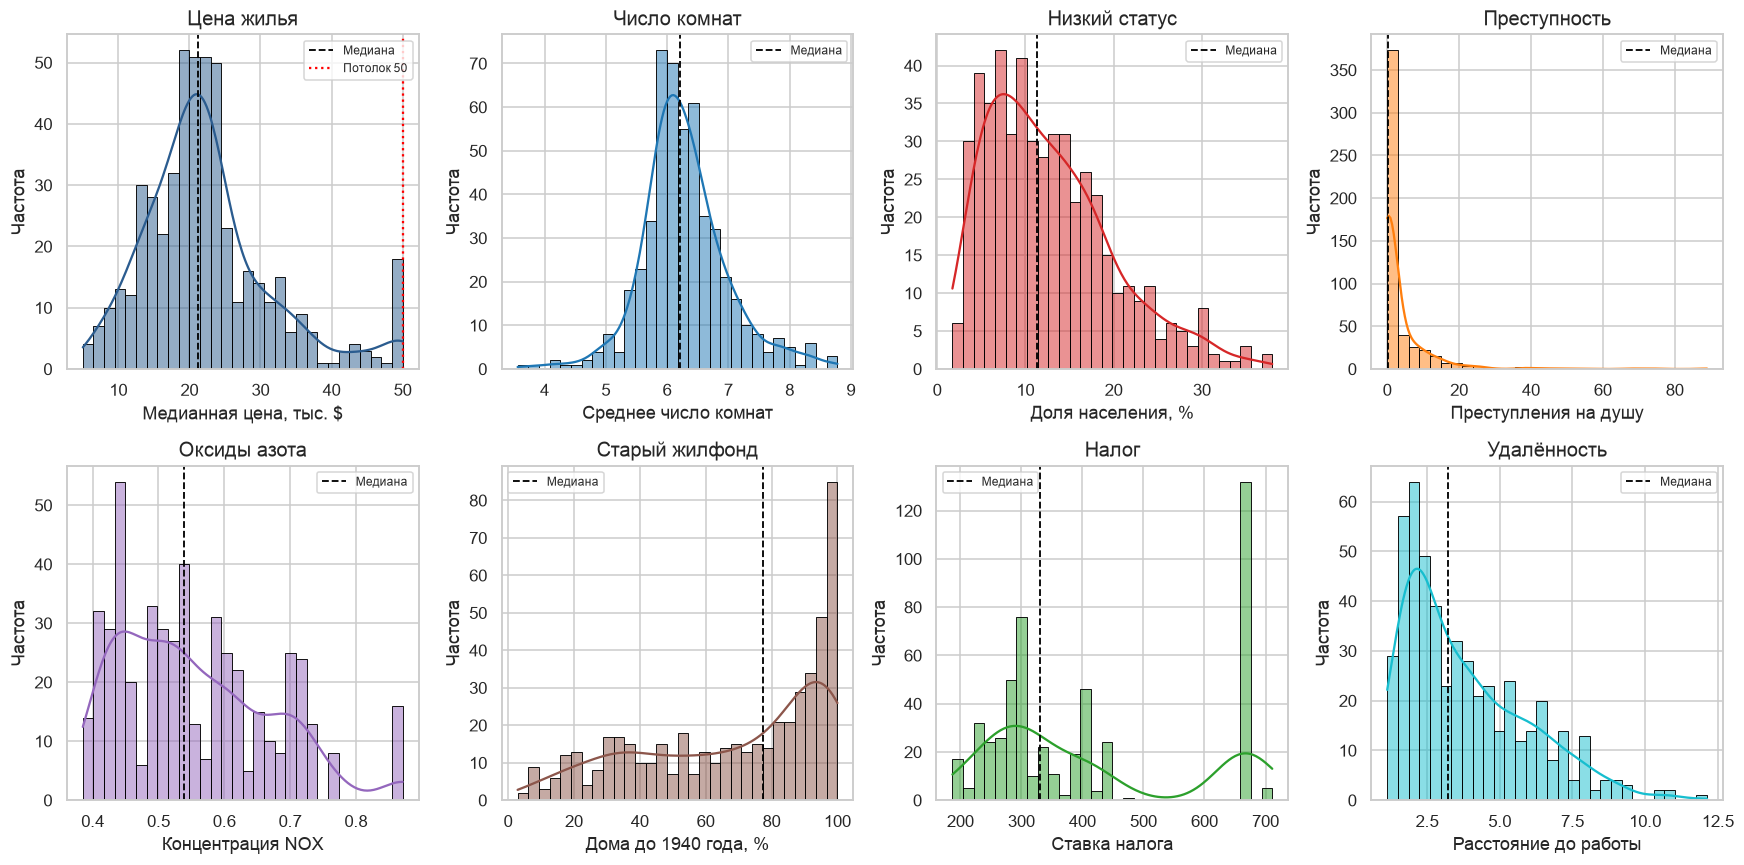

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plot_specs = [
    ("Цена жилья", "Медианная цена, тыс. $", "#2b5c8f"),
    ("Число комнат", "Среднее число комнат", "#1f77b4"),
    ("Низкий статус", "Доля населения, %", "#d62728"),
    ("Преступность", "Преступления на душу", "#ff7f0e"),
    ("Оксиды азота", "Концентрация NOX", "#9467bd"),
    ("Старый жилфонд", "Дома до 1940 года, %", "#8c564b"),
    ("Налог", "Ставка налога", "#2ca02c"),
    ("Удалённость", "Расстояние до работы", "#17becf"),
]
for ax, (col, xlabel, color) in zip(axes.ravel(), plot_specs):
    sns.histplot(df_ru[col], kde=True, ax=ax, color=color, bins=30, edgecolor="black")
    ax.axvline(df_ru[col].median(), color="black", linestyle="--", linewidth=1.2, label="Медиана")
    ax.set_title(col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Частота")
    ax.legend(fontsize=8)
axes[0, 0].axvline(50, color="red", linestyle=":", linewidth=1.5, label="Потолок 50")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Пояснение к графикам распределения

Цена жилья одновершинная, около 20–25 тыс. долларов и тонким правым хвостом. Красная линия на 50 - не естественный максимум рынка, а обрезка данных: 16 районов сложены в одну точку.

Число комнат около 6. Низкий статус смещён влево и имеет длинный правый хвост: большинство районов в диапазоне примерно 5–17%, но есть территории за 30%. Преступность почти у нуля, что видно на гистограмме - линейная модель будет чувствительна к нескольким крайним районам.

Налог даёт отдельный столбик на 666: у 132 районов ставка одна и та же. Старый жилфонд сдвинут вправо, много районов почти целиком застроены до 1940 года. Удалённость скошена: больше районов близко к центрам занятости, чем далеко.


In [4]:
feature_names = [c for c in df_ru.columns if c != "Цена жилья"]
X = df_ru[feature_names]
y = df_ru["Цена жилья"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print(f"Обучающая выборка: {X_train_scaled.shape[0]} районов, {X_train_scaled.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test_scaled.shape[0]} районов, {X_test_scaled.shape[1]} признаков")
print("Среднее и СКО после стандартизации (train, должны быть ~0 и ~1):")
check = pd.DataFrame({
    "Среднее": X_train_scaled.mean(),
    "СКО": X_train_scaled.std(ddof=0),
})
display(check.round(3))
print(f"\nСредняя цена на train: {y_train.mean():.3f} тыс. $")
print(f"Средняя цена на test:  {y_test.mean():.3f} тыс. $")


Обучающая выборка: 404 районов, 12 признаков
Тестовая выборка:  102 районов, 12 признаков
Среднее и СКО после стандартизации (train, должны быть ~0 и ~1):


,Среднее,СКО
Преступность,-0.0,1.0
Крупные участки,0.0,1.0
Доля промзон,-0.0,1.0
Река Чарльз,0.0,1.0
Оксиды азота,-0.0,1.0
Число комнат,-0.0,1.0
Старый жилфонд,-0.0,1.0
Удалённость,0.0,1.0
Налог,-0.0,1.0
Ученики/учитель,0.0,1.0



Средняя цена на train: 22.797 тыс. $
Средняя цена на test:  21.488 тыс. $


## 3. Подготовка данных

### Пояснение к предобработке

Выборка разделена `train_test_split` в доле 80/20: 404 района на обучение и 102 на проверку. `random_state=42` фиксирует разбиение, чтобы метрики воспроизводились.

Стандартизация обязательна: налог и число комнат несопоставимы по масштабу. Для каждого признака на обучающей выборке считаются среднее $\mu$ и стандартное отклонение $\sigma$, затем

$$
z = \frac{x - \mu}{\sigma}.
$$

Эти $\mu$ и $\sigma$ посчитаны **только по train** и затем применены к test. После преобразования среднее на train около 0, разброс около 1.

Цена не стандартизируется. Ошибка так остаётся в тысячах долларов: RMSE = 5 означает промах примерно на 5 000 долларов. Свободный член модели на центрированных признаках равен средней цене обучающей выборки.


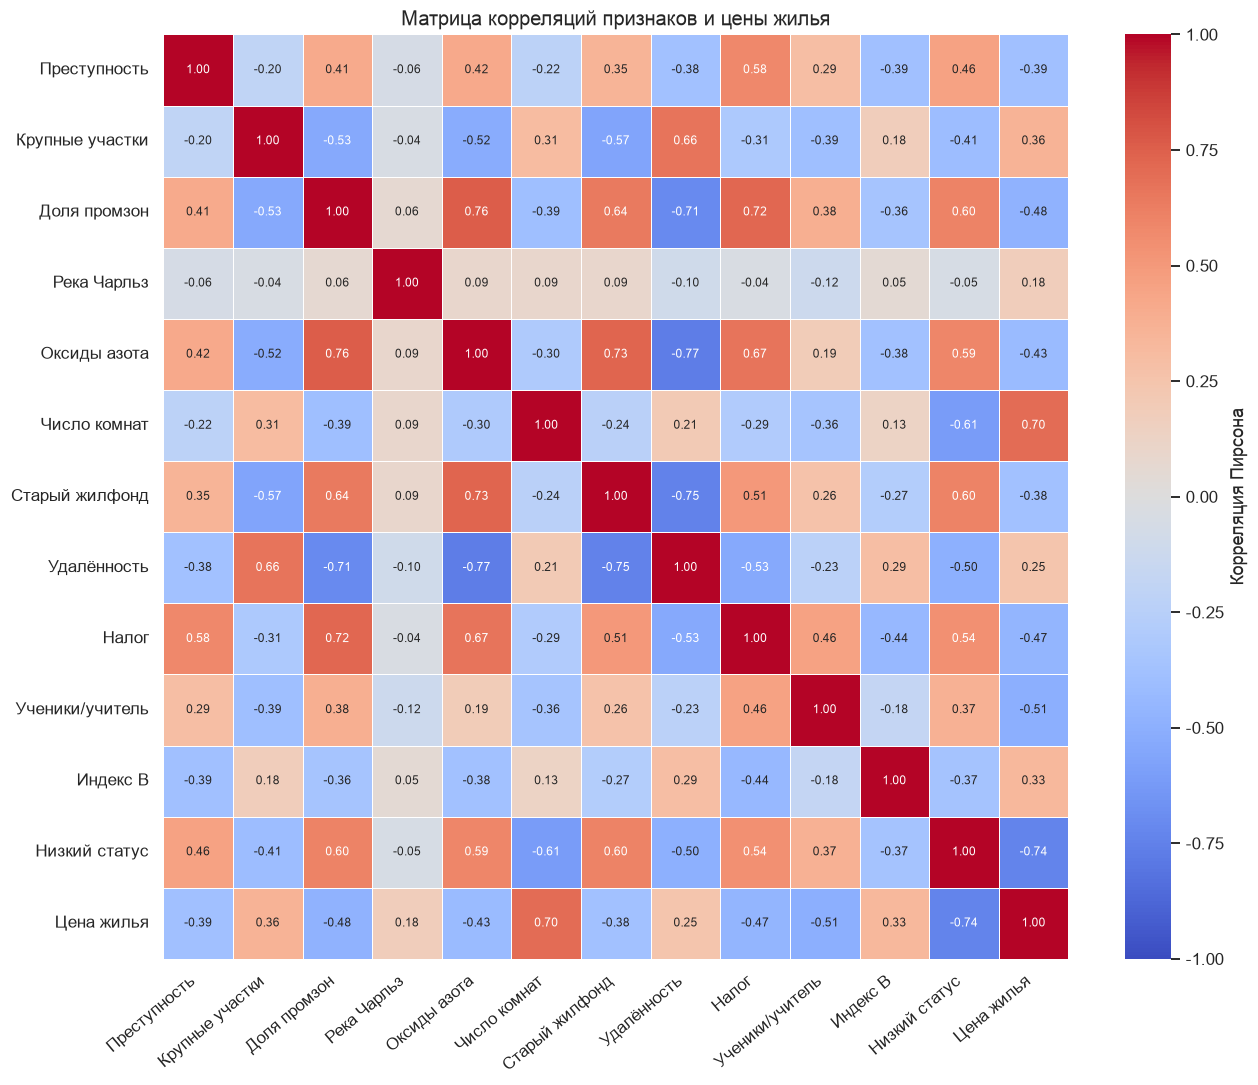

Самые сильные связи между признаками:


Признак 1,Признак 2,Корреляция
Оксиды азота,Удалённость,-0.769000
Доля промзон,Оксиды азота,0.764000
Старый жилфонд,Удалённость,-0.748000
Оксиды азота,Старый жилфонд,0.731000
Доля промзон,Налог,0.721000
Доля промзон,Удалённость,-0.708000
Оксиды азота,Налог,0.668000
Крупные участки,Удалённость,0.664000


Связь с ценой жилья:


,Корреляция
Низкий статус,-0.738
Ученики/учитель,-0.508
Доля промзон,-0.484
Налог,-0.469
Оксиды азота,-0.427
Преступность,-0.388
Старый жилфонд,-0.377
Река Чарльз,0.175
Удалённость,0.250
Индекс B,0.333


ФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (по стандартизированному train):


Признак,VIF
Оксиды азота,4.412000
Удалённость,4.166000
Доля промзон,3.658000
Налог,3.331000
Старый жилфонд,2.977000
Низкий статус,2.807000
Крупные участки,2.414000
Число комнат,1.885000
Ученики/учитель,1.776000
Преступность,1.594000


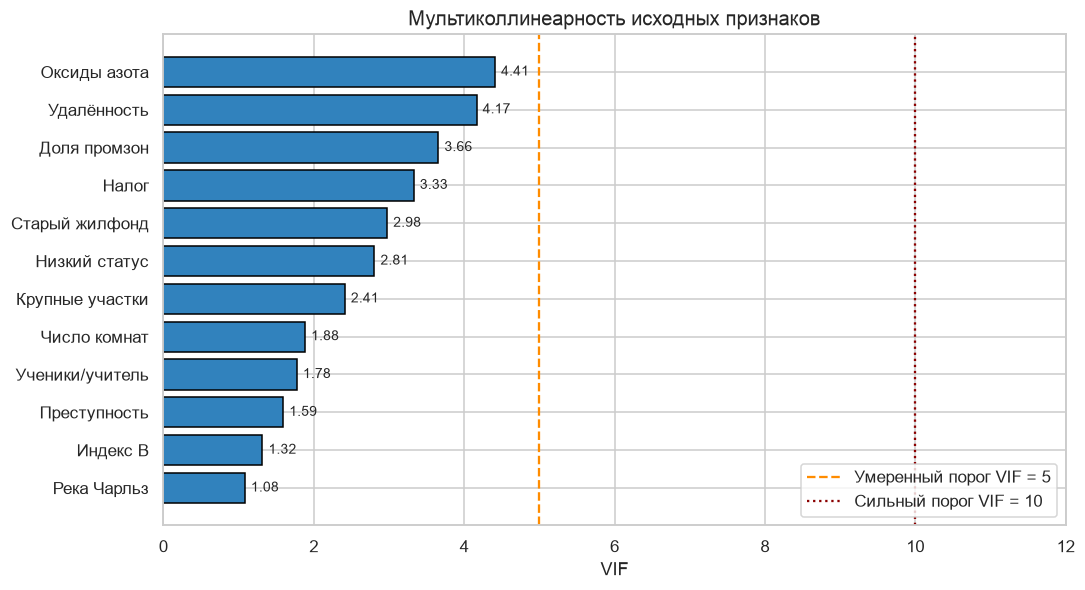

In [5]:
corr_matrix = df_ru.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, linewidths=0.4, annot_kws={"size": 8},
    cbar_kws={"label": "Корреляция Пирсона"},
)
plt.title("Матрица корреляций признаков и цены жилья")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, left in enumerate(feature_names):
    for right in feature_names[i + 1:]:
        r = corr_matrix.loc[left, right]
        pairs.append((abs(r), left, right, r))
pairs.sort(reverse=True)
print("Самые сильные связи между признаками:")
pairs_df = pd.DataFrame(
    [(left, right, r) for _, left, right, r in pairs[:8]],
    columns=["Признак 1", "Признак 2", "Корреляция"],
)
display(pairs_df.round(3).style.hide(axis="index"))

print("Связь с ценой жилья:")
display(
    corr_matrix["Цена жилья"].drop("Цена жилья").sort_values().round(3).rename("Корреляция").to_frame()
)

vif_df = pd.DataFrame({
    "Признак": feature_names,
    "VIF": [variance_inflation_factor(X_train_scaled.values, i) for i in range(len(feature_names))],
})
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
print("ФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (по стандартизированному train):")
display(vif_df.round(3).style.hide(axis="index"))

plt.figure(figsize=(10, 5.5))
order = vif_df.sort_values("VIF")
bars = plt.barh(order["Признак"], order["VIF"], color="#3182bd", edgecolor="black")
plt.axvline(5, color="darkorange", linestyle="--", linewidth=1.5, label="Умеренный порог VIF = 5")
plt.axvline(10, color="darkred", linestyle=":", linewidth=1.5, label="Сильный порог VIF = 10")
plt.xlabel("VIF")
plt.title("Мультиколлинеарность исходных признаков")
for bar in bars:
    val = bar.get_width()
    plt.text(val + 0.08, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
plt.xlim(0, 12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 4. Ход работы

### Пояснение к корреляциям и VIF

С ценой сильнее всего связаны **низкий статус** ($r = -0.74$) и **число комнат** ($r = +0.70$). Дальше идут ученики на учителя (−0.51), доля промзон (−0.48), налог (−0.47), оксиды азота (−0.43). Река Чарльз почти не связана с ценой поодиночке ($r = +0.18$).

Между признаками держится промышленный блок. Оксиды азота и удалённость коррелируют на **−0.77**, промзоны и оксиды азота на **+0.76**, старый жилфонд и удалённость на **−0.75**, оксиды азота и старый фонд на **+0.73**, промзоны и налог на **+0.72**. Дальние районы одновременно чище и новее, поэтому попарная корреляция удалённости с ценой положительная.

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

Ориентиры: VIF < 5 — зависимости почти нет; 5–10 — умеренная; > 10 — критическая. На обучающей выборке **все VIF ниже 5**. Выше остальных оксиды азота (4.41) и удалённость (4.17). Налог теперь 3.33. Число комнат, низкий статус и река почти независимы от остальных.

Жёсткой мультиколлинеарности нет. Связь внутри промышленного блока остаётся, поэтому регуляризацию и PCA всё равно имеет смысл сравнить.


In [6]:
alphas = np.logspace(-3, 3, 25)
ridge_selector = RidgeCV(alphas=alphas, cv=5).fit(X_train_scaled, y_train)
lasso_selector = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000).fit(X_train_scaled, y_train)
ridge_alpha = float(ridge_selector.alpha_)
lasso_alpha = float(lasso_selector.alpha_)
print(f"Сетка alpha: от {alphas.min():.4g} до {alphas.max():.4g}, {len(alphas)} значений")
print(f"Выбранный alpha Ridge: {ridge_alpha:.4f}")
print(f"Выбранный alpha Lasso: {lasso_alpha:.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models_orig = {
    "Линейная регрессия": LinearRegression(),
    f"Гребневая (Ridge, α={ridge_alpha:.2f})": Ridge(alpha=ridge_alpha),
    f"Лассо (Lasso, α={lasso_alpha:.3f})": Lasso(alpha=lasso_alpha, max_iter=20000),
}

results_orig = []
preds_orig = {}
for name, model in models_orig.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds_orig[name] = y_pred
    results_orig.append({
        "Модель": name,
        "R² (CV)": cv_scores.mean(),
        "R² (тест)": r2_score(y_test, y_pred),
        "RMSE (тест, тыс. $)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (тест, %)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

df_results_orig = pd.DataFrame(results_orig)
print("МОДЕЛИ НА 12 ИСХОДНЫХ ПРИЗНАКАХ")
display(df_results_orig.round(4).style.hide(axis="index"))


Сетка alpha: от 0.001 до 1000, 25 значений
Выбранный alpha Ridge: 10.0000
Выбранный alpha Lasso: 0.0178
МОДЕЛИ НА 12 ИСХОДНЫХ ПРИЗНАКАХ


Модель,R² (CV),R² (тест),"RMSE (тест, тыс. $)","MAPE (тест, %)"
Линейная регрессия,0.711000,0.639000,5.145000,18.023000
"Гребневая (Ridge, α=10.00)",0.711700,0.641300,5.128500,17.686600
"Лассо (Lasso, α=0.018)",0.711200,0.638900,5.146100,17.947300


### Пояснение к моделям на исходных признаках

- **Метрики:** $R^2 \approx 0.639$, RMSE $\approx 5.15$ тыс. долларов, MAPE $\approx 18.0\%$. CV на обучении даёт $R^2 \approx 0.71$.
- **Ridge/Lasso:** после подбора $\alpha$ (Ridge: 10, Lasso: 0.018) практически не отличаются от обычной линейной регрессии. Чуть лучше гребень: $R^2 \approx 0.641$. Сильный штраф качество не повышает.
- **Коэффициенты:** сильнее всего влияют `Низкий статус` и `Число комнат`.


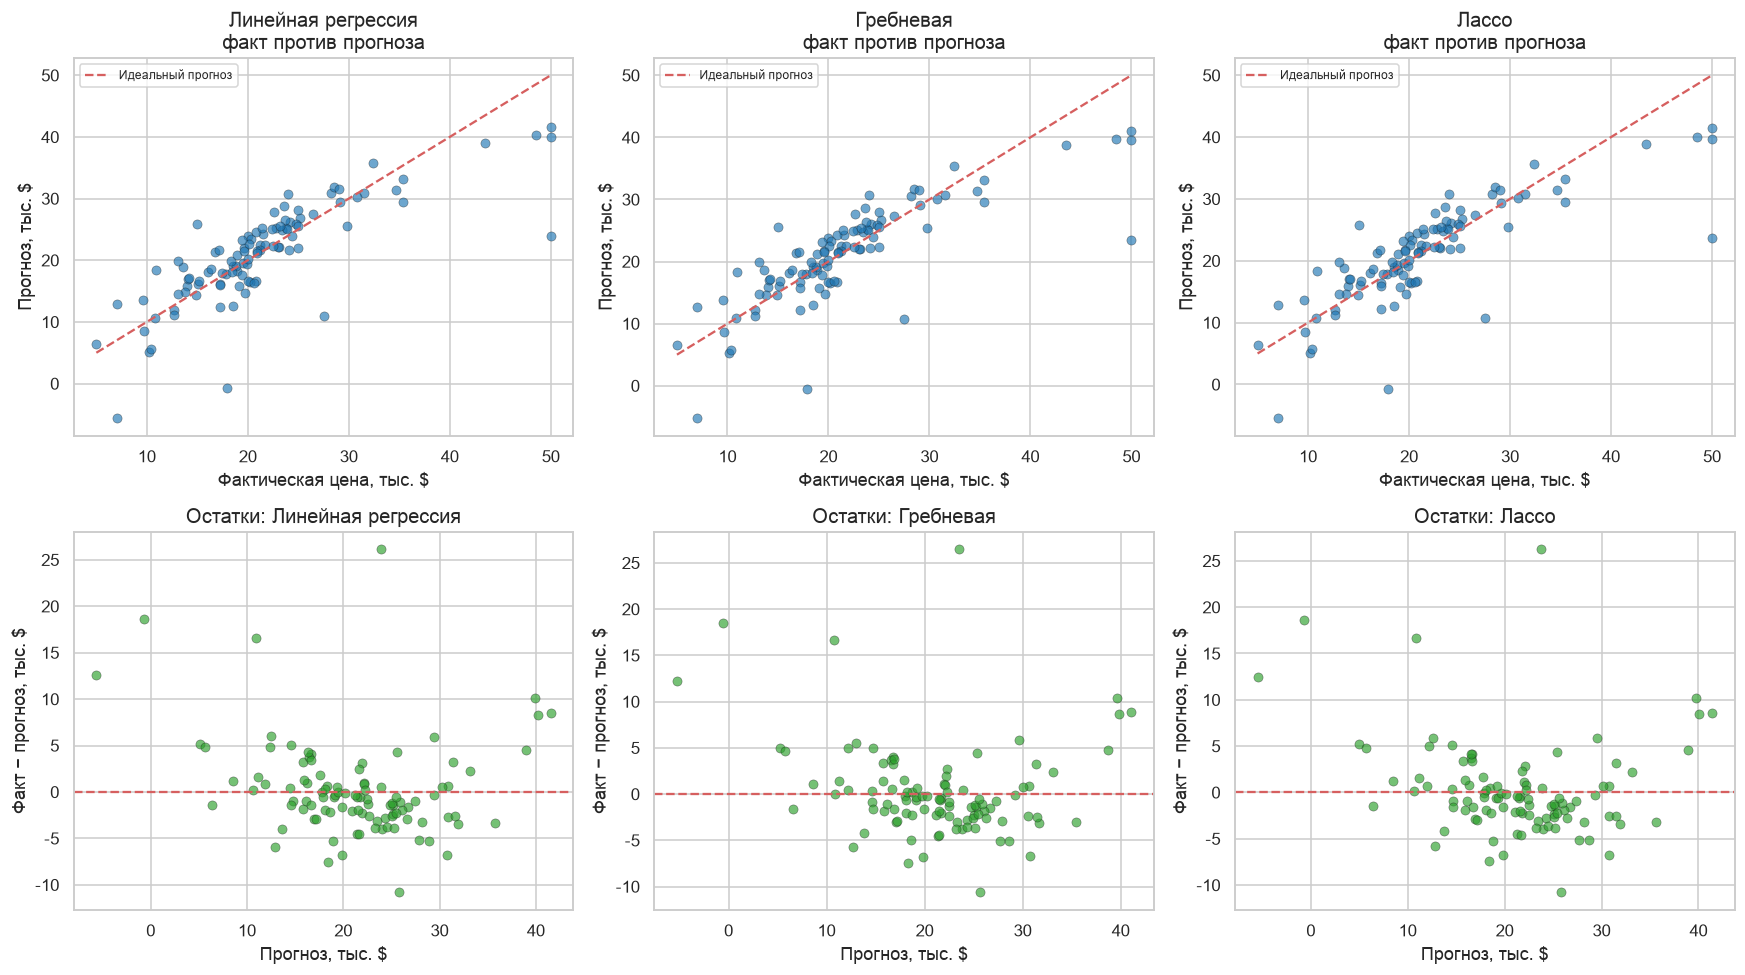

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx, (name, y_pred) in enumerate(preds_orig.items()):
    residuals = y_test.to_numpy() - y_pred
    short = name.split("(")[0].strip()

    axes[0, idx].scatter(y_test, y_pred, alpha=0.65, s=36, c="#1f77b4", edgecolor="k", linewidth=0.3)
    axes[0, idx].plot([5, 50], [5, 50], "r--", linewidth=1.5, label="Идеальный прогноз")
    axes[0, idx].set_title(f"{short}\nфакт против прогноза")
    axes[0, idx].set_xlabel("Фактическая цена, тыс. $")
    axes[0, idx].set_ylabel("Прогноз, тыс. $")
    axes[0, idx].legend(fontsize=8)

    axes[1, idx].scatter(y_pred, residuals, alpha=0.65, s=36, c="#2ca02c", edgecolor="k", linewidth=0.3)
    axes[1, idx].axhline(0, color="r", linestyle="--", linewidth=1.5)
    axes[1, idx].set_title(f"Остатки: {short}")
    axes[1, idx].set_xlabel("Прогноз, тыс. $")
    axes[1, idx].set_ylabel("Факт − прогноз, тыс. $")

plt.tight_layout()
plt.show()


### Пояснение к графикам прогноза и остатков

В середине диапазона, примерно от 12 до 35 тыс. долларов, точки держатся около диагонали. Выше 40 тыс. долларов прогноз отстаёт: фактическая цена уже обрезана на 50, а модель даёт меньше. Остатки не лежат ровной полосой вокруг нуля — разброс ошибки растёт вместе с прогнозом. Линейная регрессия, Ridge и Lasso визуально неотличимы. Рабочая модель — линейная регрессия на исходных признаках.


,Компонента,Собственное значение,Доля дисперсии,Накопленная доля
0,ГК 1,5.4718,0.4549,0.4549
1,ГК 2,1.4290,0.1188,0.5736
2,ГК 3,1.1279,0.0938,0.6674
3,ГК 4,0.8554,0.0711,0.7385
4,ГК 5,0.8223,0.0684,0.8069
5,ГК 6,0.6526,0.0542,0.8611
6,ГК 7,0.5061,0.0421,0.9032
7,ГК 8,0.3958,0.0329,0.9361
8,ГК 9,0.2289,0.0190,0.9551
9,ГК 10,0.2005,0.0167,0.9718


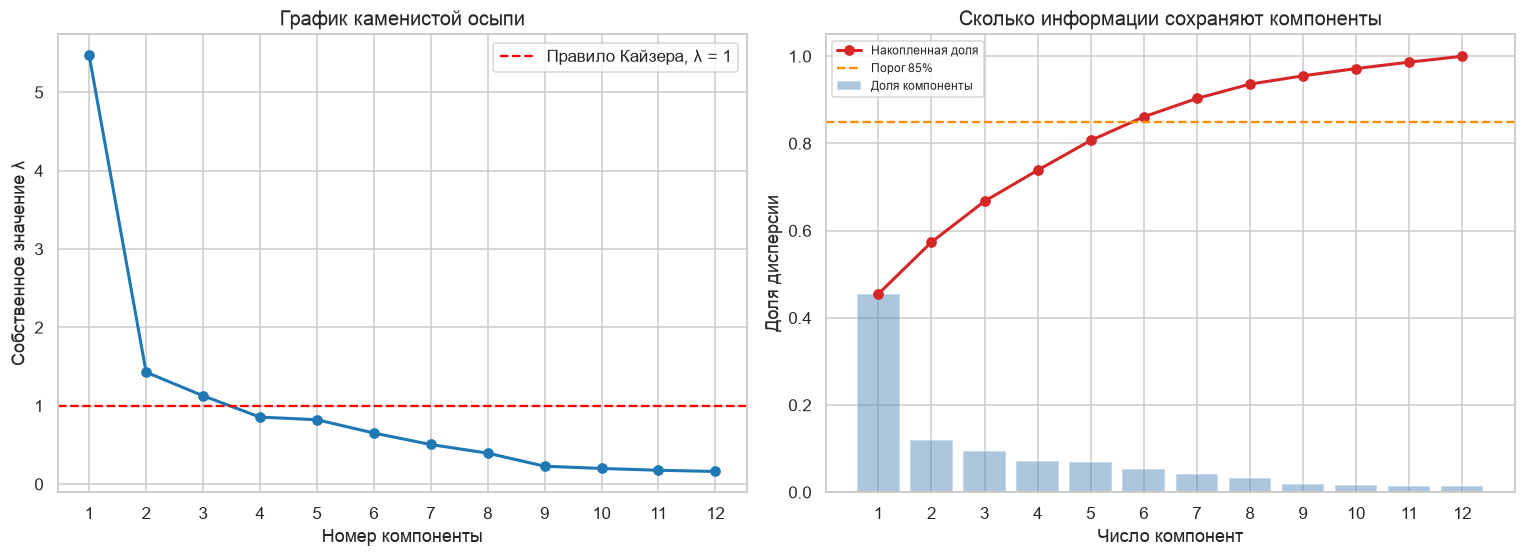

Компонент с λ ≥ 1: 3
Компонент для накопленной доли ≥ 85%: 6 (факт 86.1%)
Факторные нагрузки:


,ГК 1,ГК 2,ГК 3,ГК 4,ГК 5,ГК 6
Преступность,0.246,-0.215,-0.443,0.042,0.146,0.514
Крупные участки,-0.286,-0.173,-0.396,0.323,-0.244,0.211
Доля промзон,0.373,0.070,0.006,0.084,-0.029,0.012
Река Чарльз,0.020,0.537,-0.071,0.728,0.345,-0.159
Оксиды азота,0.367,0.227,-0.055,0.014,-0.217,0.073
Число комнат,-0.205,0.409,-0.415,-0.452,0.286,0.096
Старый жилфонд,0.338,0.257,0.106,-0.178,-0.093,0.094
Удалённость,-0.353,-0.310,-0.075,0.222,0.021,-0.067
Налог,0.333,-0.141,-0.324,0.100,0.161,0.175
Ученики/учитель,0.202,-0.403,0.196,-0.036,0.727,-0.127


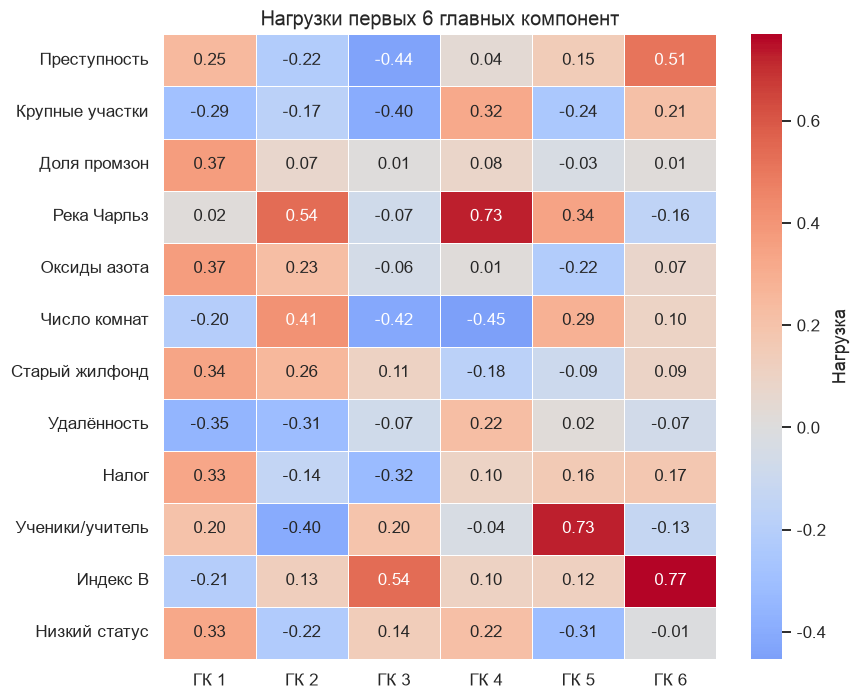

In [8]:
pca_full = PCA().fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

pca_table = pd.DataFrame({
    "Компонента": [f"ГК {i + 1}" for i in range(len(eigenvalues))],
    "Собственное значение": eigenvalues,
    "Доля дисперсии": exp_var_ratio,
    "Накопленная доля": cum_var,
})
display(pca_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
xs = np.arange(1, len(eigenvalues) + 1)
axes[0].plot(xs, eigenvalues, "o-", color="#1f77b4", linewidth=2)
axes[0].axhline(1.0, color="red", linestyle="--", label="Правило Кайзера, λ = 1")
axes[0].set_xticks(xs)
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Собственное значение λ")
axes[0].set_title("График каменистой осыпи")
axes[0].legend()

axes[1].bar(xs, exp_var_ratio, color="steelblue", alpha=0.45, label="Доля компоненты")
axes[1].plot(xs, cum_var, "o-", color="#d62728", linewidth=2, label="Накопленная доля")
axes[1].axhline(0.85, color="darkorange", linestyle="--", label="Порог 85%")
axes[1].set_xticks(xs)
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Доля дисперсии")
axes[1].set_title("Сколько информации сохраняют компоненты")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

k_opt = int(np.searchsorted(cum_var, 0.85) + 1)
print(f"Компонент с λ ≥ 1: {int((eigenvalues >= 1).sum())}")
print(f"Компонент для накопленной доли ≥ 85%: {k_opt} (факт {cum_var[k_opt - 1] * 100:.1f}%)")

pca = PCA(n_components=k_opt).fit(X_train_scaled)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"ГК {i + 1}" for i in range(k_opt)],
)
print("Факторные нагрузки:")
display(loadings.round(3))

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4,
    cbar_kws={"label": "Нагрузка"},
)
plt.title(f"Нагрузки первых {k_opt} главных компонент")
plt.tight_layout()
plt.show()


### Пояснение к PCA

Перед PCA признаки уже стандартизованы. Иначе первая компонента повторила бы налог: у него самый большой исходный разброс. Сравниваем два правила:

- Правило Кайзера: $\lambda \ge 1$ — 3 ГК (66.7% дисперсии);
- Порог 85% дисперсии — 6 ГК (86.1%).

Собственные значения резко падают после первой компоненты ($\lambda \approx 5.47$, затем 1.43 и 1.13) и дальше уходят ниже 1. Трёх компонент по Кайзеру для прогноза мало. В регрессию берём **6** компонент.

Содержательная интерпретация факторных нагрузок:

- **ГК 1** (45.5% дисперсии) — «Промышленный фон»: положительные Доля промзон (+0.37), Оксиды азота (+0.37), Старый жилфонд (+0.34), Налог (+0.33) и Низкий статус (+0.33) при отрицательных Удалённость (−0.35) и Крупные участки (−0.29). Компонента растёт в более промышленных районах и падает там, где дальше от работы.

- **ГК 2** (11.9% дисперсии) — «Река и комнаты»: положительные Река Чарльз (+0.54) и Число комнат (+0.41) при отрицательных Ученики/учитель (−0.40) и Удалённость (−0.31).

- **ГК 3** (9.4% дисперсии) — «Индекс B против преступности и комнат»: Индекс B (+0.54) при отрицательных Преступность (−0.44), Число комнат (−0.42) и Крупные участки (−0.40).

- **ГК 4** (7.1% дисперсии) — «Река против числа комнат»: Река Чарльз (+0.73) при отрицательном Число комнат (−0.45).

- **ГК 5** (6.8% дисперсии) — «Нагрузка на школы»: почти целиком Ученики/учитель (+0.73).

- **ГК 6** (5.4% дисперсии) — «Индекс B»: Индекс B (+0.77) и Преступность (+0.51). Эта ось слабо связана с промышленным фоном.

Все полученные главные компоненты ортогональны, поэтому оставшаяся связь признаков снимается.

Число комнат и низкий статус размазаны по нескольким ГК, а не собраны в одной оси. Поэтому отбрасывание компонент бьёт по прогнозу цены.

In [9]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_names = [f"ГК {i + 1}" for i in range(k_opt)]

vif_pca = pd.DataFrame({
    "Компонента": pca_names,
    "VIF": [variance_inflation_factor(X_train_pca, i) for i in range(k_opt)],
})
print("VIF главных компонент (ожидается около 1 — оси не коррелируют):")
display(vif_pca.round(3).style.hide(axis="index"))

models_pca = {
    "Линейная (PCA)": LinearRegression(),
    f"Ridge PCA (α={ridge_alpha:.2f})": Ridge(alpha=ridge_alpha),
    f"Lasso PCA (α={lasso_alpha:.3f})": Lasso(alpha=lasso_alpha, max_iter=20000),
}
results_pca = []
preds_pca = {}
for name, model in models_pca.items():
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="r2")
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    preds_pca[name] = y_pred
    results_pca.append({
        "Модель": name,
        "R² (CV)": cv_scores.mean(),
        "R² (тест)": r2_score(y_test, y_pred),
        "RMSE (тест, тыс. $)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (тест, %)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

df_results_pca = pd.DataFrame(results_pca)
print(f"МОДЕЛИ НА {k_opt} ГЛАВНЫХ КОМПОНЕНТАХ")
display(df_results_pca.round(4).style.hide(axis="index"))


VIF главных компонент (ожидается около 1 — оси не коррелируют):


Компонента,VIF
ГК 1,1.000000
ГК 2,1.000000
ГК 3,1.000000
ГК 4,1.000000
ГК 5,1.000000
ГК 6,1.000000


МОДЕЛИ НА 6 ГЛАВНЫХ КОМПОНЕНТАХ


Модель,R² (CV),R² (тест),"RMSE (тест, тыс. $)","MAPE (тест, %)"
Линейная (PCA),0.681900,0.595300,5.447600,17.463300
Ridge PCA (α=10.00),0.682800,0.598700,5.424700,17.373500
Lasso PCA (α=0.018),0.682000,0.596200,5.441700,17.425700


### Пояснение к моделям на главных компонентах

- **6 ГК (порог 85%):** $R^2 \approx 0.595$, RMSE ≈ $5.45$ тыс., MAPE ≈ $17.5\%$. Чуть лучше гребень: $R^2 \approx 0.599$. VIF всех компонент равен 1.
- **Ridge/Lasso** снова практически не отличаются от линейной модели.
- **3 ГК (Кайзер)** в регрессию не брались: вместе они держат только 66.7% дисперсии, этого для цены мало.

PCA снимает связь признаков, но по $R^2$ и RMSE прогноз **хуже**, чем на исходных признаках. Рабочая модель — гребневая регрессия на исходных стандартизованных признаках.


,Тип,Пространство,R² (CV),R² (тест),"RMSE (тест, тыс. $)","MAPE (тест, %)"
0,Линейная,Исходные 12 признаков,0.7110,0.6390,5.1450,18.0230
1,Ridge,Исходные 12 признаков,0.7117,0.6413,5.1285,17.6866
2,Lasso,Исходные 12 признаков,0.7112,0.6389,5.1461,17.9473
3,Линейная,6 главных компонент,0.6819,0.5953,5.4476,17.4633
4,Ridge,6 главных компонент,0.6828,0.5987,5.4247,17.3735
5,Lasso,6 главных компонент,0.6820,0.5962,5.4417,17.4257


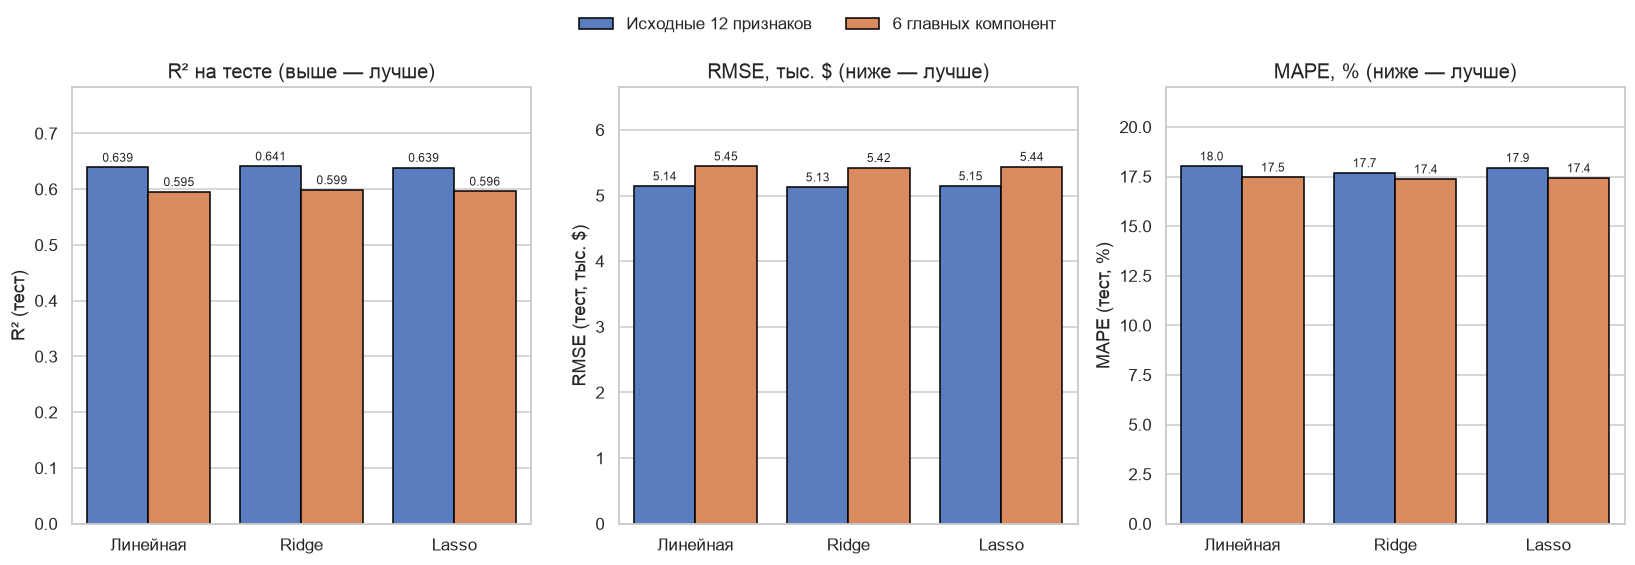

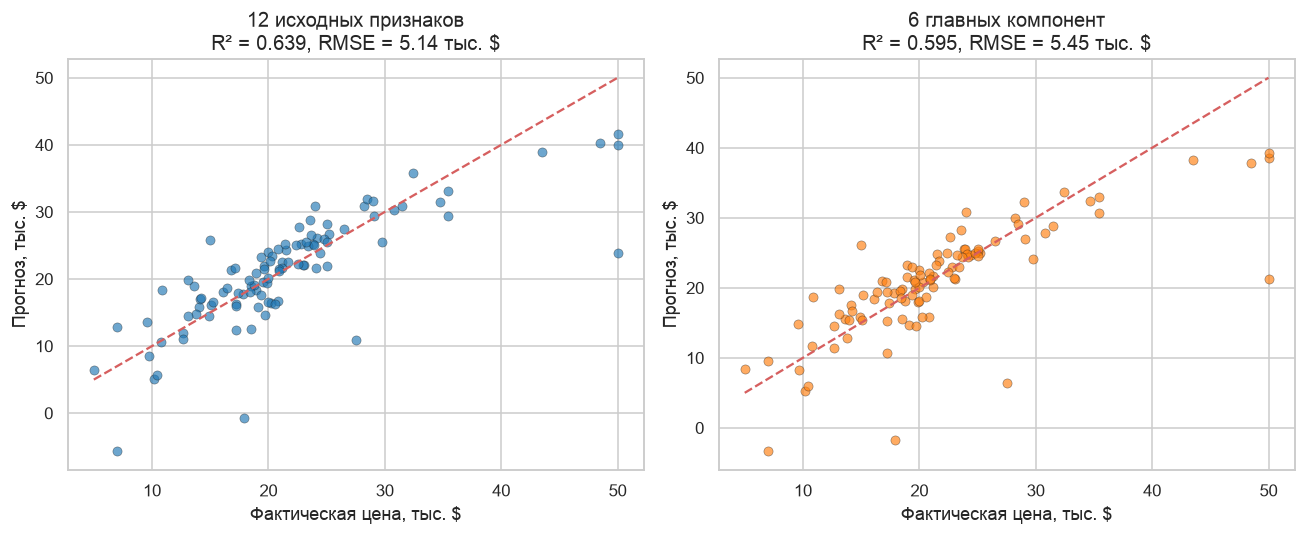

In [10]:
cmp_orig = df_results_orig.copy()
cmp_pca = df_results_pca.copy()
cmp_orig["Пространство"] = "Исходные 12 признаков"
cmp_pca["Пространство"] = f"{k_opt} главных компонент"
cmp_orig["Тип"] = ["Линейная", "Ridge", "Lasso"]
cmp_pca["Тип"] = ["Линейная", "Ridge", "Lasso"]
all_models = pd.concat([cmp_orig, cmp_pca], ignore_index=True)
show_cols = [
    "Тип", "Пространство", "R² (CV)", "R² (тест)",
    "RMSE (тест, тыс. $)", "MAPE (тест, %)",
]
display(all_models[show_cols].round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
metric_specs = [
    ("R² (тест)", "R² на тесте (выше — лучше)", ".3f"),
    ("RMSE (тест, тыс. $)", "RMSE, тыс. $ (ниже — лучше)", ".2f"),
    ("MAPE (тест, %)", "MAPE, % (ниже — лучше)", ".1f"),
]
for ax, (metric, title, fmt) in zip(axes, metric_specs):
    sns.barplot(
        data=all_models, x="Тип", y=metric, hue="Пространство",
        ax=ax, edgecolor="black",
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, all_models[metric].max() * 1.22)
    for container in ax.containers:
        ax.bar_label(container, fmt=f"%{fmt}", fontsize=8, padding=2)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

lin_name = "Линейная регрессия"
pca_lin_name = "Линейная (PCA)"
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title, color in [
    (axes[0], preds_orig[lin_name], "12 исходных признаков", "#1f77b4"),
    (axes[1], preds_pca[pca_lin_name], f"{k_opt} главных компонент", "#ff7f0e"),
]:
    ax.scatter(y_test, pred, alpha=0.65, s=36, c=color, edgecolor="k", linewidth=0.3)
    ax.plot([5, 50], [5, 50], "r--", linewidth=1.5)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_title(f"{title}\nR² = {r2:.3f}, RMSE = {rmse:.2f} тыс. $")
    ax.set_xlabel("Фактическая цена, тыс. $")
    ax.set_ylabel("Прогноз, тыс. $")
plt.tight_layout()
plt.show()


### Пояснение к сравнению

1. **Лучший блок** — исходные признаки. Чуть впереди гребень: $R^2 \approx 0.641$, RMSE ≈ $5.13$ тыс., MAPE ≈ $17.7\%$. Обычная регрессия рядом: $R^2 \approx 0.639$, RMSE ≈ $5.15$ тыс., MAPE ≈ $18.0\%$.
2. **6 ГК** хуже по $R^2$ и RMSE: $R^2 \approx 0.599$, RMSE ≈ $5.42$ тыс. MAPE ≈ $17.4\%$ почти тот же. PCA здесь не повышает точность.


In [11]:
coef_table = pd.DataFrame({
    "Признак": feature_names,
    "Линейная": models_orig["Линейная регрессия"].coef_,
    f"Ridge α={ridge_alpha:.2f}": models_orig[f"Гребневая (Ridge, α={ridge_alpha:.2f})"].coef_,
    f"Lasso α={lasso_alpha:.3f}": models_orig[f"Лассо (Lasso, α={lasso_alpha:.3f})"].coef_,
})
coef_table = coef_table.sort_values("Линейная", key=lambda s: s.abs(), ascending=False)
print("КОЭФФИЦИЕНТЫ НА СТАНДАРТИЗИРОВАННЫХ ПРИЗНАКАХ")
print("Единица: тыс. $ цены при увеличении признака на 1 стандартное отклонение")
display(coef_table.round(3).style.hide(axis="index"))
print(f"\nСвободный член линейной модели: {models_orig['Линейная регрессия'].intercept_:.3f} тыс. $")
print("Нули среди коэффициентов лассо:", int(np.sum(np.abs(models_orig[f'Лассо (Lasso, α={lasso_alpha:.3f})'].coef_) < 1e-8)))


КОЭФФИЦИЕНТЫ НА СТАНДАРТИЗИРОВАННЫХ ПРИЗНАКАХ
Единица: тыс. $ цены при увеличении признака на 1 стандартное отклонение


Признак,Линейная,Ridge α=10.00,Lasso α=0.018
Низкий статус,-3.527000,-3.437000,-3.535000
Число комнат,3.349000,3.337000,3.358000
Удалённость,-3.041000,-2.736000,-2.901000
Оксиды азота,-1.828000,-1.595000,-1.738000
Ученики/учитель,-1.815000,-1.766000,-1.784000
Индекс B,1.063000,1.047000,1.043000
Река Чарльз,0.808000,0.808000,0.790000
Преступность,-0.721000,-0.697000,-0.677000
Крупные участки,0.511000,0.445000,0.485000
Старый жилфонд,-0.268000,-0.249000,-0.231000



Свободный член линейной модели: 22.797 тыс. $
Нули среди коэффициентов лассо: 0


### Пояснение к коэффициентам

Признаки стандартизованы, поэтому коэффициент показывает, на сколько тысяч долларов меняется прогноз цены при росте признака на одно стандартное отклонение.

Свободный член ≈ **22.80 тыс. $** — средняя цена на обучающей выборке.

Ранжирование влияния (по модулю коэффициента линейной модели):

- Низкий статус ≈ −3.53 — самый сильный признак. Согласуется с корреляцией $r \approx -0.74$.
- Число комнат ≈ +3.35 — больше комнат, дороже дом ($r \approx +0.70$).
- Удалённость ≈ −3.04 — при прочих равных дальше от работы дешевле. Знак не совпадает с простой корреляцией (+0.25): плюс дальних районов уже учтён в оксидах азота и доле промзон.
- Оксиды азота ≈ −1.83 — выше загрязнение, ниже цена.
- Ученики/учитель ≈ −1.81 — в районах с перегруженными школами жильё дешевле.
- Индекс B ≈ +1.06, река Чарльз ≈ +0.81, преступность ≈ −0.72.
- Крупные участки ≈ +0.51, старый жилфонд ≈ −0.27.
- Налог ≈ +0.16, доля промзон ≈ −0.10 — почти нулевой вклад. Попарно налог связан с ценой отрицательно (−0.47), но этот минус уже сидит в промышленном блоке.

Сравнение линейной модели, Ridge и Lasso. После подбора $\alpha$ (Ridge: 10, Lasso: 0.018) коэффициенты почти совпадают. Lasso не обнулил ни один вес. Порядок признаков не меняется: цену в основном определяют низкий статус, число комнат и удалённость.


## 5. Заключение

1. На датасете Boston Housing построены линейная, гребневая и лассо-регрессия с метриками RMSE, $R^2$ и MAPE. Признаков 12, целевая переменная — цена жилья.
2. В разделе **«Описание датасета»** разобраны распределения, корреляции и VIF. Жёсткой мультиколлинеарности нет: все VIF ниже 5, выше остальных оксиды азота (4.41) и удалённость (4.17). Промышленный блок при этом связан: оксиды азота и удалённость, $r = -0.77$.
3. Подготовка: train/test 80/20, `StandardScaler` только на train. Для Ridge и Lasso $\alpha$ подобран по CV (10 и 0.018). Сильная регуляризация качество не повышает.
4. Лучшая модель — гребневая регрессия на исходных признаках: $R^2 \approx 0.641$, RMSE ≈ $5.13$ тыс., MAPE ≈ $17.7\%$. Обычная регрессия почти та же: $R^2 \approx 0.639$.
5. PCA: подписи главных компонент получены из нагрузок. По правилу Кайзера значимы **3 ГК** (66.7% дисперсии), для прогноза взяты **6 ГК** (86.1%). На них качество ниже: $R^2 \approx 0.599$, RMSE ≈ $5.42$ тыс.
6. **Итог:** рабочая модель — гребневая регрессия на стандартизованных исходных признаках. PCA снимает связь признаков, но точность не повышает.


## 6. Список источников

1. Harrison D., Rubinfeld D. L. Hedonic prices and the demand for clean air // Journal of Environmental Economics and Management. — 1978. — Vol. 5. — P. 81–102.
2. Hastie T., Tibshirani R., Friedman J. The Elements of Statistical Learning. — 2nd ed. — Springer, 2009.
3. Bishop C. M. Pattern Recognition and Machine Learning. — Springer, 2006.
4. Джеймс Г., Уиттен Д., Хасти Т., Тибширани Р. Введение в статистическое обучение. — М.: ДМК Пресс, 2016.
5. Boston Housing dataset, Kaggle: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset


